# Analyse exploratoire des données

Nous connaissons peu de choses à propos de ces données, et même si nous les avons nous-mêmes produites, il est tout de même nécessaire de les examiner en profondeur afin de découvrir d'éventuels patrons et voir si, et comment elles peuvent être classées.

In [2]:
import os, math, random
import numpy as np
import pandas as pd
import polars as pl

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

import umap
import shap

import geopandas as gpd
from shapely.geometry import Point


Commençons par lire les données afin d'effectuer quelques vérifications élémentaires et évaluer la répartition des classes d'arbres sans parcourir l'ensemble du jeu de données. Nous allons réduire la taille de l’ensemble en regroupant les échantillons par leur tree_id. Cela permet de diminuer environ 2,5 le nombres d'échantillons et obtnir une taille bien plus compacte, ce qui est préférable et moins bruité pour la phase d’exploration.

In [3]:
PARQUET_PATH = "https://drive.google.com/uc?export=download&id=1eEhK6wZzaRLeQAgDTFC8fuGj9bVN6gev"

# Lazy scan (doesn't load all at once)
lf = pl.scan_parquet(PARQUET_PATH)

# Peek schema
lf.collect_schema()


Schema([('species', Int32),
        ('dbh_mm', Float32),
        ('height_dm', Float32),
        ('crown_area_m2', Float32),
        ('tree_id', Int32),
        ('X_WGS84', Float32),
        ('Y_WGS84', Float32),
        ('doy', Int32),
        ('ndvi', Float32),
        ('split', String),
        ('Blue', Int32),
        ('Green', Int32),
        ('Red', Int32),
        ('B05', Int32),
        ('B06', Int32),
        ('B07', Int32),
        ('NIR', Int32),
        ('B8a', Int32),
        ('SWIR1', Int32),
        ('SWIR2', Int32)])

In [4]:

species_map = {10:"spruce", 20:"pine", 100:"beech"}

# let's count samples and tress per species
tree_counts = (
    lf.select(["tree_id", "species"])
      .unique()
      .group_by("species")
      .agg(pl.len().alias("n_trees"))
      .sort("species")
      .collect()
      .to_pandas()
)

sample_counts = (
    lf.group_by("species")
      .agg(pl.len().alias("n_samples"))
      .sort("species")
      .collect()
      .to_pandas()
)

display(tree_counts)
display(sample_counts)



,species,n_trees
0,10,15996
1,20,30539
2,100,4607


,species,n_samples
0,10,795818
1,20,1588370
2,100,260043


In [5]:
# Let's reduce the dataset to one sample per tree_id 

boa_labels = ["Blue", "Green", "Red", "B05", "B06", "B07", "NIR", "B8a", "SWIR1", "SWIR2"]
feature_cols = (
    boa_labels
    + ["dbh_mm", "height_dm", "crown_area_m2", "X_WGS84", "Y_WGS84", "doy", "ndvi"]
)

tree_lf = (
    lf.group_by("tree_id")
      .agg([
          pl.first("species").alias("species"),
          pl.first("split").alias("split"),
          pl.len().alias("n_samples_tree"),
          *[pl.median(c).alias(c) for c in feature_cols],
      ])
)

tree_df = tree_lf.collect().to_pandas()
tree_df["species_name"] = tree_df["species"].map(species_map)
print(tree_df.shape)
tree_df.head()

(51142, 22)


,tree_id,species,split,n_samples_tree,Blue,Green,Red,B05,B06,B07,...,SWIR1,SWIR2,dbh_mm,height_dm,crown_area_m2,X_WGS84,Y_WGS84,doy,ndvi,species_name
0,91245,20,train,61,293.0,450.0,391.0,708.0,1636.0,1931.0,...,1184.0,585.0,365.0,234.0,31.334034,12.880407,52.059284,205.0,0.685120,pine
1,227688,20,val,58,203.0,346.5,232.5,592.0,1678.0,2049.5,...,1092.5,566.5,413.0,247.0,40.347206,8.072473,51.952801,204.5,0.812199,pine
2,91903,20,train,52,281.0,445.0,363.5,685.0,1690.0,2004.5,...,1146.0,548.0,286.0,228.0,19.347685,12.878099,52.023365,204.0,0.705686,pine
3,269120,20,train,53,237.0,367.0,250.0,558.0,1740.0,2162.0,...,882.0,401.0,141.0,132.0,5.582111,11.714080,52.459492,204.0,0.790522,pine
4,280788,20,train,60,238.5,390.0,264.5,588.5,1817.0,2261.0,...,1065.5,479.5,267.0,202.0,16.819313,14.333158,53.481960,206.0,0.800026,pine


## Visualisation de la distribution des données et de la séparation entre les classes

In [6]:
sns.set_context("talk")

# Create geometry column from lon/lat
geometry = [
    Point(xy) for xy in zip(tree_df["X_WGS84"], tree_df["Y_WGS84"])
]

gdf_trees = gpd.GeoDataFrame(
    tree_df.copy(),
    geometry=geometry,
    crs="EPSG:4326"  # WGS84
)

gdf_trees.head()


,tree_id,species,split,n_samples_tree,Blue,Green,Red,B05,B06,B07,...,SWIR2,dbh_mm,height_dm,crown_area_m2,X_WGS84,Y_WGS84,doy,ndvi,species_name,geometry
0,91245,20,train,61,293.0,450.0,391.0,708.0,1636.0,1931.0,...,585.0,365.0,234.0,31.334034,12.880407,52.059284,205.0,0.685120,pine,POINT (12.88041 52.05928)
1,227688,20,val,58,203.0,346.5,232.5,592.0,1678.0,2049.5,...,566.5,413.0,247.0,40.347206,8.072473,51.952801,204.5,0.812199,pine,POINT (8.07247 51.9528)
2,91903,20,train,52,281.0,445.0,363.5,685.0,1690.0,2004.5,...,548.0,286.0,228.0,19.347685,12.878099,52.023365,204.0,0.705686,pine,POINT (12.8781 52.02337)
3,269120,20,train,53,237.0,367.0,250.0,558.0,1740.0,2162.0,...,401.0,141.0,132.0,5.582111,11.714080,52.459492,204.0,0.790522,pine,POINT (11.71408 52.45949)
4,280788,20,train,60,238.5,390.0,264.5,588.5,1817.0,2261.0,...,479.5,267.0,202.0,16.819313,14.333158,53.481960,206.0,0.800026,pine,POINT (14.33316 53.48196)


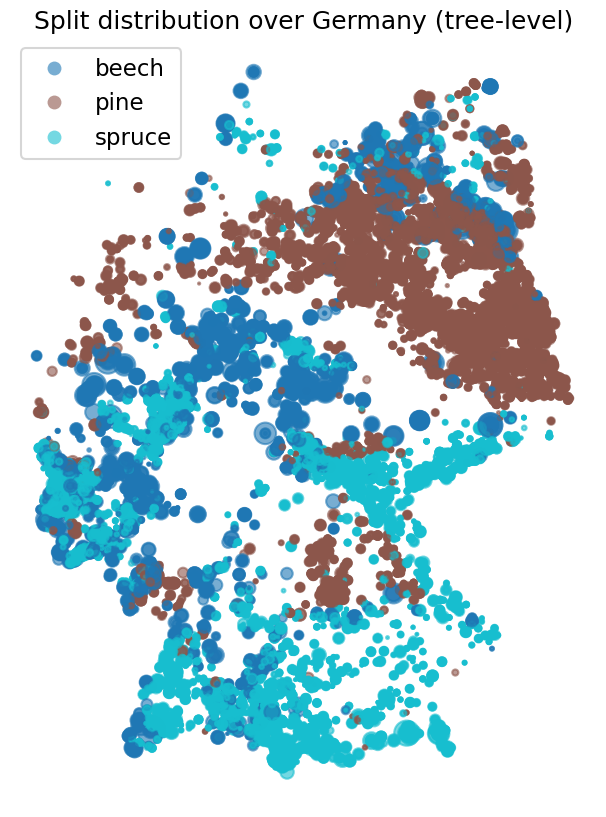

In [7]:
fig, ax = plt.subplots(figsize=(8,10))

# Plot trees
gdf_trees.plot(
    ax=ax,
    column="species_name",
    categorical=True,
    legend=True,
    markersize="crown_area_m2",
    alpha=0.6
)

ax.set_title("Split distribution over Germany (tree-level)")
ax.set_axis_off()

plt.show()

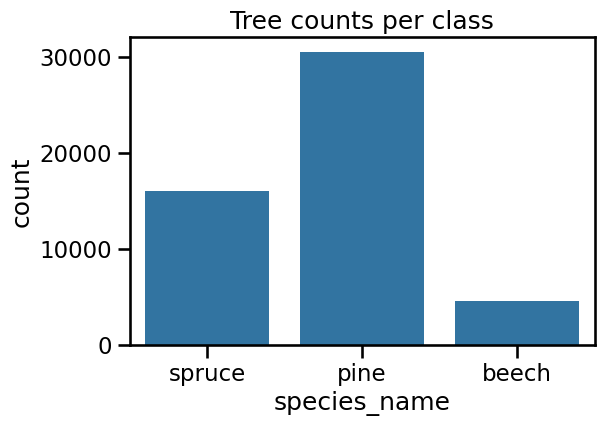

In [8]:
# Class distribution by trees
plt.figure(figsize=(6,4))
sns.countplot(data=tree_df, x="species_name", order=[species_map[10], species_map[20], species_map[100]])
plt.title("Tree counts per class")
plt.show()


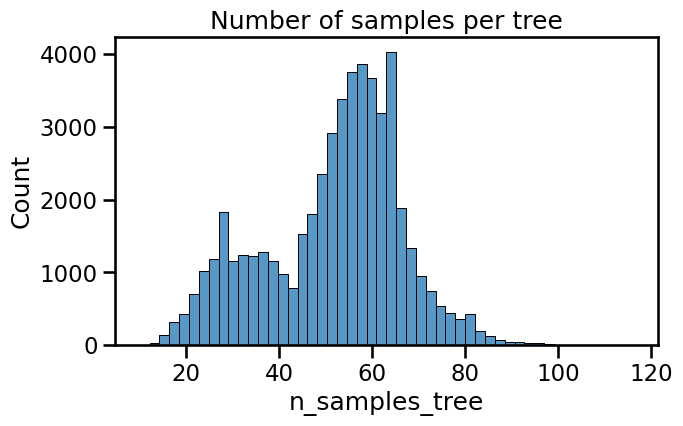

In [9]:
# Samples per tree
plt.figure(figsize=(7,4))
sns.histplot(tree_df["n_samples_tree"], bins=50)
plt.title("Number of samples per tree")
plt.xlabel("n_samples_tree")
plt.show()


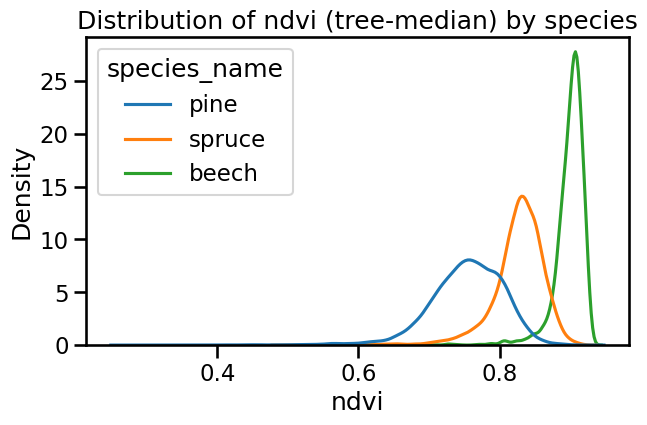

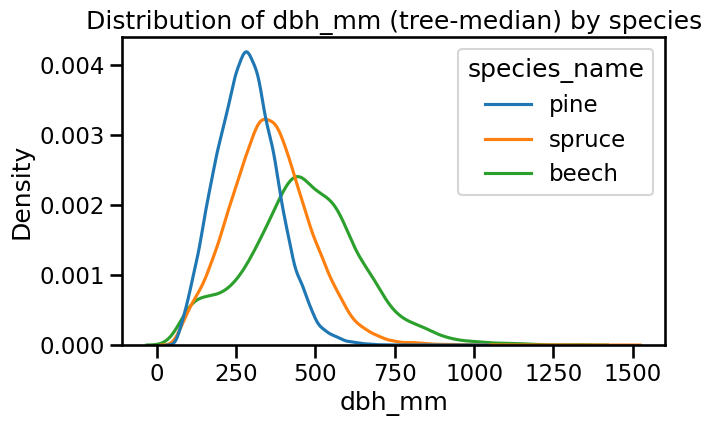

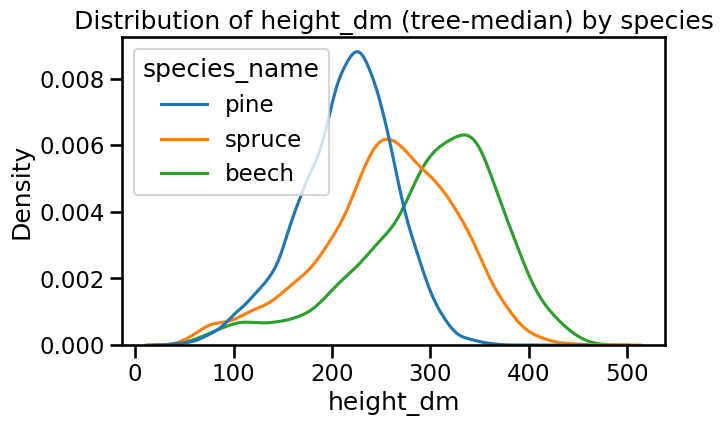

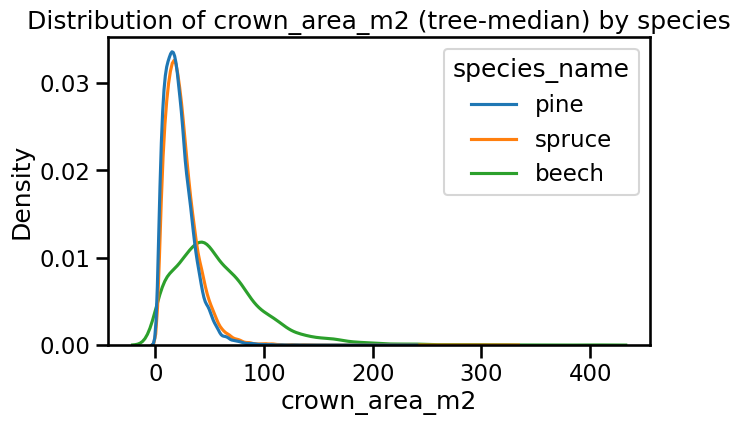

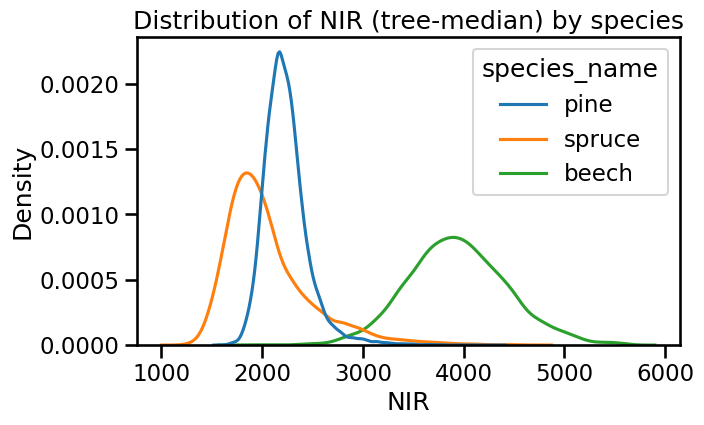

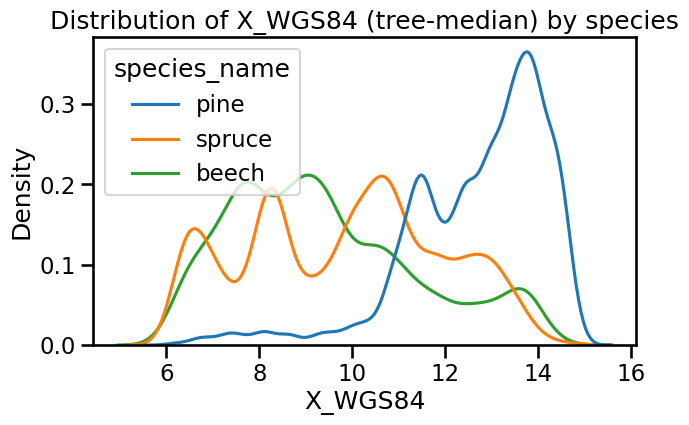

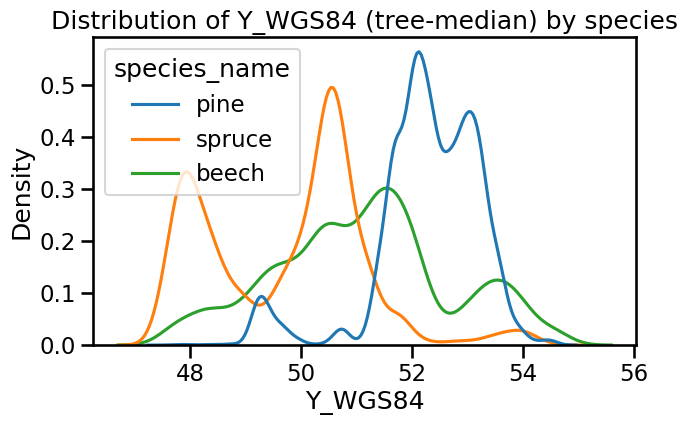

In [10]:
# Feature distributions by class (pick a few)
plot_feats = ["ndvi", "dbh_mm", "height_dm", "crown_area_m2", "NIR", "X_WGS84", "Y_WGS84"]
for f in plot_feats:
    plt.figure(figsize=(7,4))
    sns.kdeplot(data=tree_df, x=f, hue="species_name", common_norm=False)
    plt.title(f"Distribution of {f} (tree-median) by species")
    plt.show()

## Mise en évidence des corrélations entre variables et réduction de la dimensionnalité pour faciliter la reconnaissance des patrons

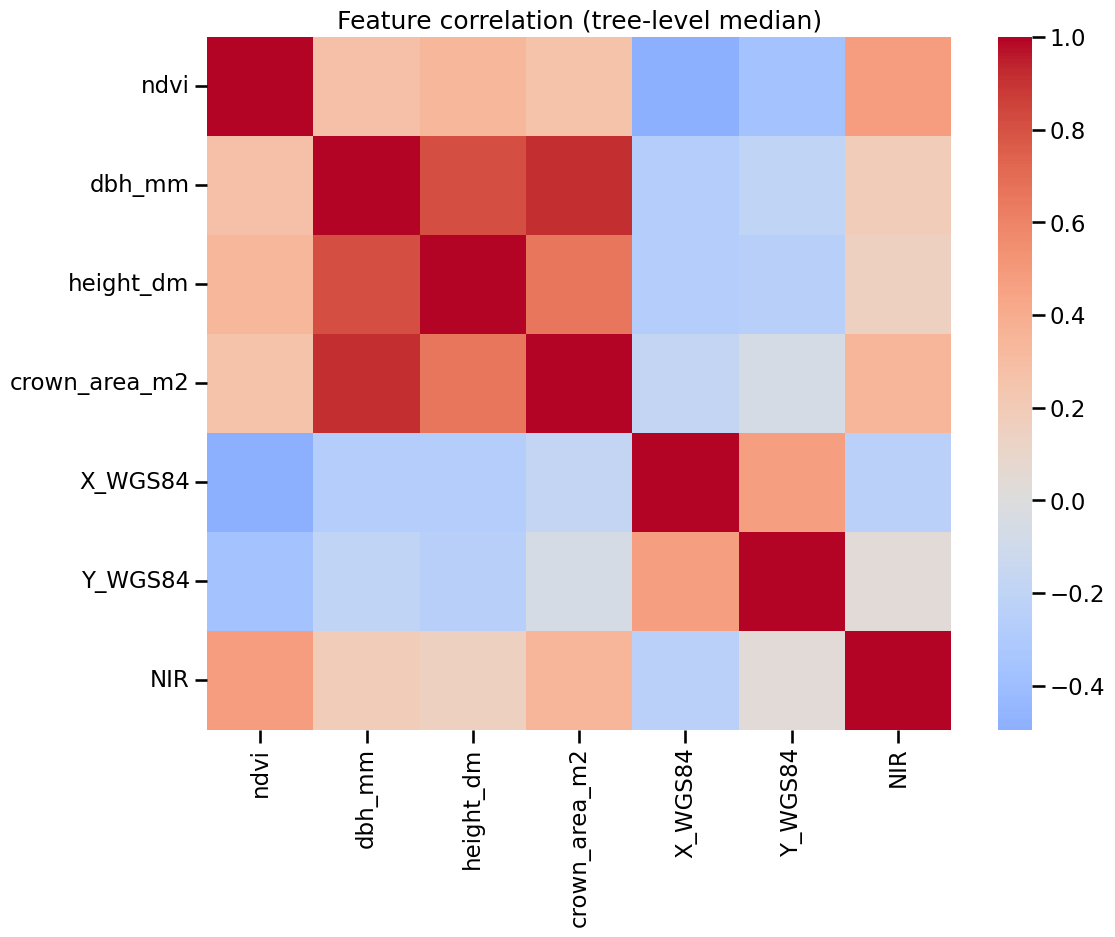

In [11]:
corr_cols = ["ndvi", "dbh_mm", "height_dm", "crown_area_m2", "X_WGS84", "Y_WGS84", "NIR"]
corr = tree_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12,9))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature correlation (tree-level median)")
plt.show()


## Mise à l’échelle des variables (Feature Scaling)

La mise à l’échelle des variables numériques transforme celles-ci afin qu’elles soient sur des plages comparables, évitant ainsi que les variables à grande échelle ne dominent l’apprentissage du modèle. Le choix de la méthode dépend de la distribution des données et de la présence de valeurs aberrantes. Voici quelques méthodes courantes :

1. Mise à l’échelle par maximum absolu: chaque valeur est divisée par la valeur absolue maximale de la variable, ce qui ramène l’ensemble des données dans l’intervalle [−1, 1].

- Avantages : Simple, préserve les signes.

- Inconvénients : Sensible aux valeurs aberrantes (il est possible d'identifier un maximum approprié au préalable, puis d'appliquer cette méthode).

2. Mise à l’échelle Min-Max: rééchelonne les variables dans un intervalle fixe, généralement [0, 1], tout en conservant l'aspect de la distribution.

- Avantages : Préserve les distances relatives.

- Inconvénients : Sensible aux valeurs aberrantes (il est possible d'identifier des minimum et maximum appropriés au préalable).

3. Normalisation: met à l’échelle chaque valeur de sorte que sa norme euclidienne soit égale à 1, en se concentrant sur la direction plutôt que sur l’amplitude.

- Avantages : Idéale pour les similarités cosinus, les données textuelles.

- Inconvénients : Ne traite pas chaque caractéristique séparément de façon indépendante.

4. Standardisation (Score Z): centre les valeurs pour obtenir une moyenne nulle et une variance égale à 1.

- Avantages : Fonctionne bien pour les données distribuées normalement; améliore la convergence de la descente de gradient.

- Inconvénients : Modérément affectée par les valeurs aberrantes.

5. Mise à l’échelle robuste: utilise la médiane et les percentiles, limite l’influence des valeurs extrêmes.

- Avantage : Idéal pour les données asymétriques comportant des valeurs extrêmes.

- Inconvénient : Sensibilité moindre aux faibles variations.

In [ ]:
# Mise à l’échelle / harmonisation
# Nous allons mettre à l’échelle les variables des caractéristiques au niveau de l’arbre et appliquer une simple standardisation, tant pour UMAP que pour le RandomForestClassifier.
# À noter : la moyenne et l’écart-type sont calculés sur les données d’entraînement et appliqués ensuite aux données de test.

scaler_tree = StandardScaler()
Xtr_tree = scaler_tree.fit_transform(tree_df[tree_df["split"].isin(["train", "val"])][feature_cols])
ytr_tree = tree_df[tree_df["split"].isin(["train", "val"])]["species"].values
ytr_tree_names = tree_df[tree_df["split"].isin(["train", "val"])]["species_name"]

Xte_tree = scaler_tree.transform(tree_df[tree_df.split == "test"][feature_cols])
yte_tree = tree_df[tree_df.split == "test"]["species"].values
yte_tree_names = tree_df[tree_df.split == "test"]["species_name"]

print(feature_cols)
print(np.round(Xte_tree[:5,:], 2))

print("Train & val size:", Xtr_tree.shape[0])
print("Test size:", Xte_tree.shape[0])

['Blue', 'Green', 'Red', 'B05', 'B06', 'B07', 'NIR', 'B8a', 'SWIR1', 'SWIR2', 'dbh_mm', 'height_dm', 'crown_area_m2', 'X_WGS84', 'Y_WGS84', 'doy', 'ndvi']
[[ 0.36  0.24  0.63  0.41 -0.31 -0.5  -0.54 -0.42  0.17  0.12 -0.62 -0.13
  -0.53  1.14  0.59  0.42 -0.97]
 [-0.38 -0.98 -0.63 -0.85 -0.75 -0.66 -0.46 -0.63 -0.77 -0.75  0.86  0.51
   0.25  0.19 -1.03  0.13  0.25]
 [-0.74  0.44 -0.91  0.1   1.09  1.2   1.26  1.07 -1.06 -1.29 -1.48 -1.88
  -0.96 -1.47 -0.06 -0.26  1.46]
 [ 0.18 -0.02 -0.15 -0.08 -0.09 -0.1  -0.07 -0.15 -0.29 -0.43  0.73  0.58
   0.7  -0.42 -0.99  0.7   0.16]
 [-0.46  0.02 -0.64  0.27  1.72  1.9   1.7   2.03  1.24  0.59  2.66  1.87
   3.7  -0.12 -0.26  0.7   1.5 ]]
Train & val size: 37376
Test size: 13766


In [13]:
umap_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.05,
    n_components=2,
    metric="euclidean"
)
emb = umap_model.fit_transform(Xtr_tree)
emb_te = umap_model.transform(Xte_tree)

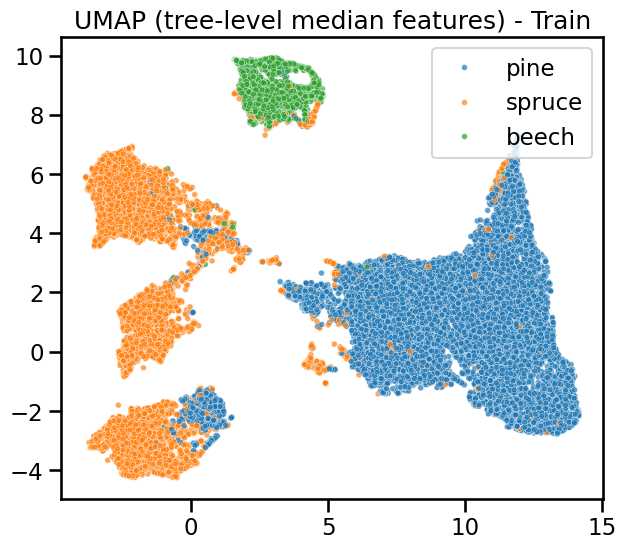

In [14]:

plt.figure(figsize=(7,6))
sns.scatterplot(
    x=emb[:,0], y=emb[:,1],
    hue=ytr_tree_names,
    s=18, alpha=0.7
)
plt.title("UMAP (tree-level median features) - Train")
plt.legend(loc="best")
plt.show()

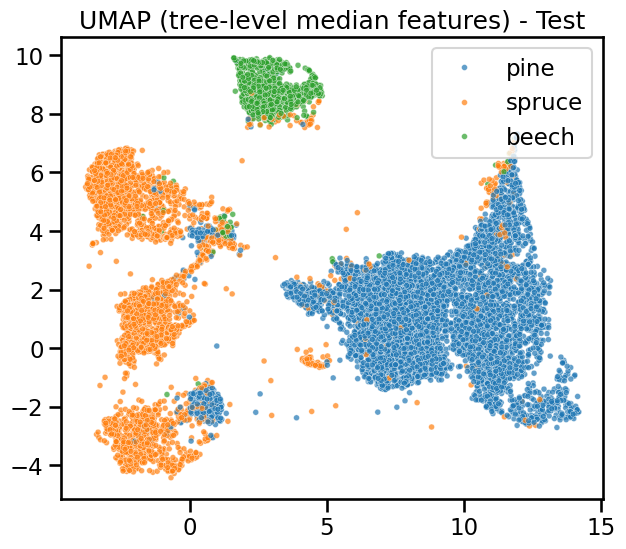

In [15]:
plt.figure(figsize=(7,6))
sns.scatterplot(
    x=emb_te[:,0], y=emb_te[:,1],
    hue=yte_tree_names,
    s=18, alpha=0.7
)
plt.title("UMAP (tree-level median features) - Test")
plt.legend(loc="best")
plt.show()

## Mesure de l’importance des variables

L’importance des variables mesure la contribution de chaque variable à la précision prédictive du modèle, ce qui permet d’identifier les variables les plus influentes.

Elle quantifie dans quelle mesure chaque variable d’entrée contribue aux prédictions du modèle. Cela aide à comprendre quelles sont les variables qui ont le plus d’influence sur la variable(s) cible(s). C’est un aspect crucial pour l’interprétabilité du modèle, la sélection des variables lorsque l’on dispose d’un grand nombre d’attributs, et l’amélioration des performances du modèle.

*Comment l’importance des variables est-elle calculée?*

Il existe différentes méthodes, par exemple :

1. Diminution moyenne de l’impureté (MDI) : Il s’agit de la méthode la plus courante (celle appliquée dans l’exemple de Random Forest Classifier ci-dessous). Elle calcule l’importance d’une variable en fonction de la diminution totale de l’impureté (par exemple, l’impureté de Gini ou l’entropie) qu’apporte cette variable lorsqu’elle est utilisée pour séparer les données à travers tous les arbres de la forêt. Plus une variable réduit l’impureté, plus elle est considérée comme importante.

2. Importance par permutation : Cette méthode évalue l’importance d’une variable en mesurant comment la performance du modèle change lorsque les valeurs de cette variable sont remaniées de façon aléatoire. Si le mélange d’une variable entraîne une baisse significative de la précision du modèle, cela indique que la variable est importante.

3. Valeurs SHAP : Les valeurs SHAP (SHapley Additive exPlanations) fournissent une mesure unifiée de l’importance des variables en quantifiant la contribution de chaque variable aux prédictions individuelles. Cette méthode est particulièrement utile pour comprendre l’impact des variables dans les modèles complexes.

*Pourquoi l’importance des variables est-elle importante?*

- Interprétabilité du modèle : Comprendre quelles variables sont les plus influentes aide les parties prenantes à interpréter les décisions du modèle, ce qui facilite la confiance et la validation des prédictions du modèle.

- Sélection des variables : En identifiant et en se concentrant sur les variables les plus importantes, on peut simplifier le modèle, éviter le surapprentissage (overfitting) et réduire les temps d’entraînement.

- Optimisation des performances : Prioriser les variables essentielles peut mener à de meilleures performances, car cela permet au modèle de se concentrer sur les informations les plus pertinentes. 

In [16]:
baseline = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)
baseline.fit(Xtr_tree, ytr_tree)

importances = baseline.feature_importances_
for feature, importance in zip(feature_cols, importances):
    print(feature,":", importance)


Blue : 0.1277835808763866
Green : 0.0632881955361817
Red : 0.057532701985420244
B05 : 0.0404984697491531
B06 : 0.07307633856744017
B07 : 0.11064022002396366
NIR : 0.0864523855446708
B8a : 0.12128715197657272
SWIR1 : 0.08319156741262143
SWIR2 : 0.03741733067025
dbh_mm : 0.004519228297339602
height_dm : 0.006914150780057882
crown_area_m2 : 0.006949879885708817
X_WGS84 : 0.022349874587852373
Y_WGS84 : 0.10396732237834944
doy : 0.00351638329613481
ndvi : 0.050615218431896696


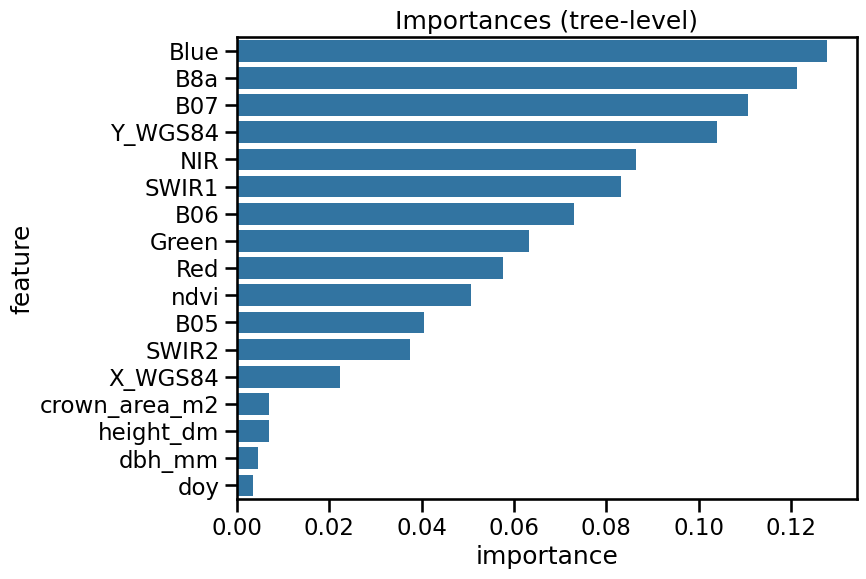

In [ ]:
# Visualisons aussi les résultats.
df_imp = pd.DataFrame({'feature': feature_cols, 'importance': importances})
df_imp = df_imp.sort_values('importance', ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(data=df_imp, y="feature", x="importance")
plt.title(f"Importances (tree-level)")
plt.show()

(1376, 17, 3)


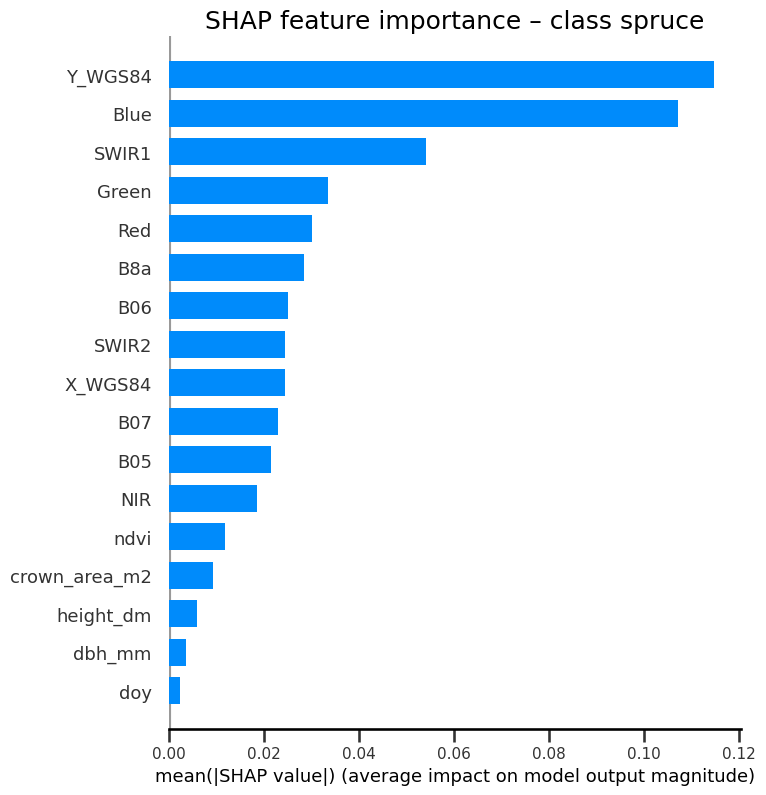

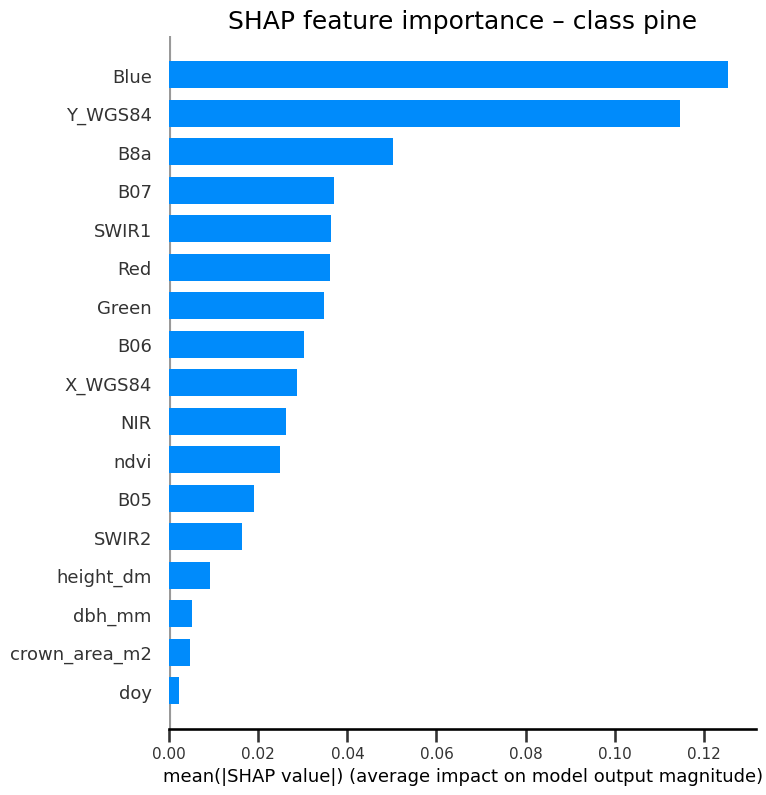

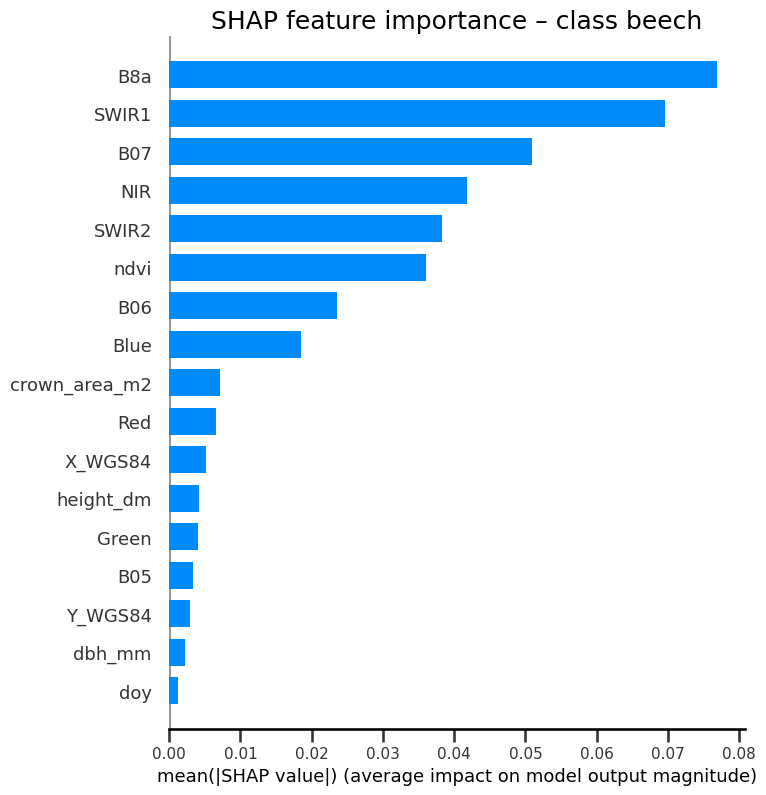

In [ ]:
# Voici les résultats d’un autre type de méthode de calcul de l’importance des variables

# # pour tester rapidement cet exemple :
explainer = shap.TreeExplainer(
    baseline,
    feature_names=feature_cols
)
# # pour une meilleure interprétation des données:
# SHAP  is time-taking so let's take a smaller subset of our data to work with
# X_sub, _, _, _ = train_test_split(
#     Xtr_tree,
#     ytr_tree,
#     train_size=0.02,        # e.g. take 10% subset
#     stratify=ytr_tree,     # preserves class proportions
#     random_state=42
# )
# explainer = shap.TreeExplainer(
#     baseline,
#     data=X_sub,
#     feature_names=feature_cols,
#     feature_perturbation="interventional",
#     model_output="probability"
# )

X_sub, _, _, _ = train_test_split(
    Xte_tree,
    yte_tree,
    train_size=0.1,        
    stratify=yte_tree,     
    random_state=42
)

shap_values = explainer.shap_values(X_sub, check_additivity=False)

print(shap_values.shape)

for k, class_label in enumerate(["spruce", "pine", "beech"]):
    shap.summary_plot(
        shap_values[:, :, k],
        X_sub,
        feature_names=feature_cols,
        plot_type="bar",
        show=False
    )
    plt.title(f"SHAP feature importance – class {class_label}")
    plt.tight_layout()
    plt.show()

### Exercice
Supprimons les coordonnées géographiques et le jour de l'année de notre jeu de données et vérifions deux éléments :

1. À quoi ressemblent les variables restantes ?
    - Indices : Modifiez la liste feature_cols, recréez les ensembles de variables et d’étiquettes <(Xtr_tree, ytr_tree) et (Xte_tree, yte_tree)>, puis appliquez à nouveau le modèle UMAP et affichez les résultats.
2. L’ordre d’importance des autres variables change-t-il ?
    - Indices : Reprenez le test d’importance du classifieur Random Forest avec les nouveaux ensembles de variables et d’étiquettes.